# Exploring soil modeling in soilice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice.src_soil import model as origModel
from src_soil_kcryo import model as newModel

In [3]:
from matplotlib.gridspec import GridSpec

In [4]:
def profilePlot(out):
    t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title = (
        out.t,
        out.qI,
        out.qT,
        out.qB,
        out.thetaL,
        out.thetaI,
        out.psie,
        out.psif,
        out.T,
        out.title
    )
    i=np.arange(0,len(t),30)
    
    # --- Create figure and layout ---
    fig = pl.figure(figsize=(8,4))
    gs = GridSpec(2, 3, figure=fig)
    
    # ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[:, 0])
    ax3 = fig.add_subplot(gs[:, 1])
    ax4 = fig.add_subplot(gs[:, 2])
    
    # --- Left plot (potentials) ---
    ax2.plot(psif[0,:].T, z, 'c', label='Frozen potential')
    ax2.plot(psie[0,:].T, z, 'b', label='Matric potential')
    ax2.plot(psif[i,:].T, z, 'c')
    ax2.plot(psie[i,:].T, z, 'b')
    # line_h, = ax2.plot([], [], 'g', label='Hydraulic head')
    line_h, = ax2.plot([], [], 'g')
    ax2.set_ylim(2, 0)
    ax2.set_xlim(-6, 0)
    ax2.set_xlabel('Head (m)')
    ax2.set_ylabel('Depth (m)')
    ax2.legend(loc=1)
    ax2.grid()
    
    # --- Middle plot (water content) ---
    ax3.plot(thetaL[0,:].T, z, 'b', label='Liquid')
    ax3.plot(thetaI[0,:].T, z, 'c', label='Ice')
    ax3.plot(thetaL[i,:].T, z, 'b')
    ax3.plot(thetaI[i,:].T, z, 'c')
    
    ax3.set_ylim(2, 0)
    ax3.set_xlim(0, 0.5)
    ax3.set_yticklabels([])
    ax3.set_xlabel('Water content (-)')
    ax3.legend(loc=1)
    ax3.grid()
    
    # --- Right plot (temperature) ---
    ax4.plot(T[i,:].T, z, 'r', label='Temperature')
    ax4.set_ylim(2, 0)
    ax4.set_xlim(-2.5,2.5)
    ax4.set_yticklabels([])
    ax4.set_xlabel('Temperature (°C)')
    ax4.grid()
    
    # --- Adjust spacing ---
    pl.subplots_adjust(wspace=0.05, hspace=0.4)
    
    fig.suptitle(title)

In [5]:
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=1.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=1.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=True        # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=True   # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=0.          # 0. no flow lower BC, 1.0 free draining lowerBC
opts['groundHeatFlux']=0.        # 0. no specified ground heat flux; 1. use specified ground heat flux.

In [6]:
# Import soil parameters:
from soilice.pars_loam import pars

# Import constants:
from soilice.constants import const

# Convert parameter units into days:
pars['Ks']=pars['Ks']*86400
pars['kappa_org']=pars['kappa_org']*86400
pars['kappa_soil']=pars['kappa_soil']*86400
const['kappa_air']=const['kappa_air']*86400
const['kappa_ice']=const['kappa_ice']*86400
const['kappa_liq']=const['kappa_liq']*86400

In [7]:
# Space grid
zMax=2.
dz=0.01
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,20,0.1) # days
nt=len(t)
dt=t[1]-t[0]

In [8]:
baseModel=origModel(opts,rtol=1e-8)
baseModel.zGrid(np.hstack([0,np.cumsum(dz)]))
baseModel.tGrid(t[0],t[-1],t[1]-t[0])
baseModel.setPars(pars)
baseModel.setConst(const)

soilice ran successfully!
               runtime:      0.37 seconds
    Mass balance error: -1.00e+02 %
                         7.24e-05 kg
  Energy balance error: -1.00e+02 %
                         3.03e-01 J


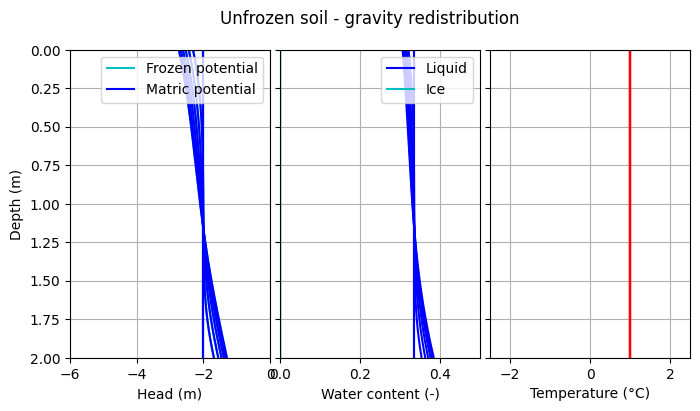

In [12]:
# Run first scenario
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
sim1=newModel(opts,rtol=1e-8)
for k,v in vars(baseModel).items():
    setattr(sim1,k,v)
sim1.BCs(TTop=1,TBot=1)
sim1.ICs(psi0=-2,T0=1)
out1=sim1.run()
out1.title=f"Unfrozen soil - gravity redistribution"
profilePlot(out1)
pl.savefig('figures/04_cryo01.png')

soilice ran successfully!
               runtime:      4.45 seconds
    Mass balance error: -1.00e+02 %
                        -9.47e-06 kg
  Energy balance error: -1.17e-03 %
                         3.96e+00 J


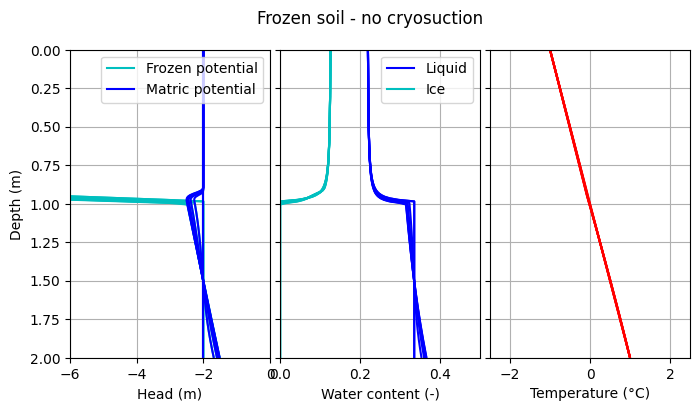

In [11]:
# Run 2nd scenario
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
sim2=newModel(opts,rtol=1e-8)
for k,v in vars(baseModel).items():
    setattr(sim2,k,v)
sim2.BCs(TTop=-1,TBot=1)
sim2.ICs(psi0=-2,T0=[-1,1])
out2=sim2.run()
out2.title=f"Frozen soil - no cryosuction"
profilePlot(out2)
pl.savefig('figures/04_cryo02.png')


soilice ran successfully!
               runtime:      0.72 seconds
    Mass balance error: -1.00e+02 %
                        -3.68e-05 kg
  Energy balance error:  5.24e-03 %
                        -3.34e+01 J


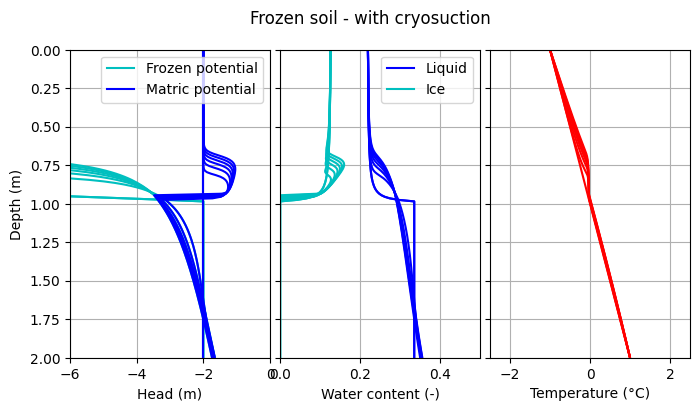

In [16]:
# Run 3rd scenario
opts['cryoflow']=1.              # 0. flow based on psie; 1. flow based on psif 
sim3=newModel(opts,rtol=1e-8)
for k,v in vars(baseModel).items():
    setattr(sim3,k,v)
sim3.BCs(TTop=-1,TBot=1)
sim3.ICs(psi0=-2,T0=[-1,1])
out3=sim3.run()
out3.title=f"Frozen soil - with cryosuction"
profilePlot(out3)
pl.savefig('figures/04_cryo03.png')

/Users/ani378/pyenvs/3-12/lib/python3.12/site-packages/scipy/integrate/_ode.py:431: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


soilice ran successfully!
               runtime:      1.63 seconds
    Mass balance error: -1.00e+02 %
                         5.24e+01 kg
  Energy balance error: -5.60e+03 %
                        -1.76e+07 J


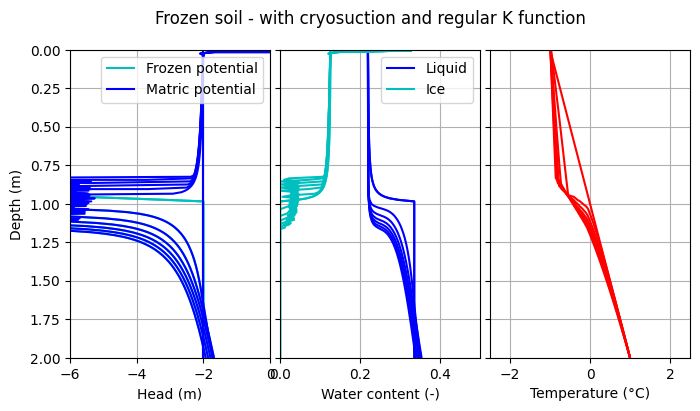

In [15]:
# Run 4th scenario
opts['cryoflow']=1.              # 0. flow based on psie; 1. flow based on psif 
sim4=origModel(opts,rtol=1e-8)
for k,v in vars(baseModel).items():
    setattr(sim4,k,v)
sim4.BCs(TTop=-1,TBot=1)
sim4.ICs(psi0=-2,T0=[-1,1])
out4=sim4.run()
out4.title=f"Frozen soil - with cryosuction and regular K function"
profilePlot(out4)
pl.savefig('figures/04_cryo04.png')